# Retail Sales Analysis with Python

## Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Loading and Inspecting the data

In [2]:
import os
from scipy import stats
df = pd.read_csv('retail_sales_data.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(f"Dataset shape: {df.shape}")
print (f"\nColumn names: \n {df.columns.tolist()}")

Dataset shape: (142, 8)

Column names: 
 ['CustomerID', 'InvoiceNo', 'InvoiceDate', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'Country']


In [3]:
#Showing the datatypes of each column
print(f"Data types: {df.dtypes}")

Data types: CustomerID             object
InvoiceNo              object
InvoiceDate    datetime64[ns]
StockCode              object
Description            object
Quantity                int64
UnitPrice             float64
Country                object
dtype: object


In [4]:
#Showing the first 10 rows of the dataset
print(f"First 10 rows:") 
df.head(10)

First 10 rows:


,CustomerID,InvoiceNo,InvoiceDate,StockCode,Description,Quantity,UnitPrice,Country
0,C001,INV-1001,2024-01-03,SKU-A01,Ceramic Coffee Mug,6,4.50,Kenya
1,C002,INV-1002,2024-01-05,SKU-B02,Scented Candle Set,3,12.99,Uganda
2,C003,INV-1003,2024-01-07,SKU-C03,Wooden Picture Frame,2,8.75,Kenya
3,C001,INV-1004,2024-01-10,SKU-D04,Linen Throw Blanket,1,24.99,Kenya
4,C004,INV-1005,2024-01-12,SKU-A01,Ceramic Coffee Mug,12,4.50,Tanzania
5,C005,INV-1006,2024-01-15,SKU-E05,Glass Vase Set,4,15.00,Kenya
6,C002,INV-1007,2024-01-18,SKU-F06,Bamboo Desk Organiser,2,11.50,Uganda
7,C006,INV-1008,2024-01-20,SKU-G07,Personalised Notebook,5,7.25,Rwanda
8,C003,INV-1009,2024-01-22,SKU-B02,Scented Candle Set,1,12.99,Kenya
9,C007,INV-1010,2024-01-25,SKU-H08,Herb Garden Kit,3,18.00,Kenya


In [5]:
#Showing the last 5 rows of the dataset
print(f"Last 5 rows:" )
df.tail(5)

Last 5 rows:


,CustomerID,InvoiceNo,InvoiceDate,StockCode,Description,Quantity,UnitPrice,Country
137,C042,INV-1138,2024-12-20,SKU-X24,Jute Shopping Bag,30,6.00,Kenya
138,C028,INV-1139,2024-12-22,SKU-A01,Ceramic Coffee Mug,50,4.50,Kenya
139,C003,INV-1140,2024-12-27,SKU-N14,Recycled Glass Bowl,8,13.75,Kenya
140,C043,INV-1141,2024-12-28,SKU-B02,Scented Candle Set,18,12.99,Tanzania
141,C004,INV-1142,2024-12-30,SKU-G07,Personalised Notebook,12,7.25,Tanzania


In [6]:
#Statistical Summary
print(f"Statistical Summary ")
df.describe(include='all')

Statistical Summary 


,CustomerID,InvoiceNo,InvoiceDate,StockCode,Description,Quantity,UnitPrice,Country
count,142,142,142,142,142,142.000000,142.000000,142
unique,50,142,NaN,26,26,NaN,NaN,4
top,C001,INV-1001,NaN,SKU-A01,Ceramic Coffee Mug,NaN,NaN,Kenya
freq,6,1,NaN,18,18,NaN,NaN,98
mean,NaN,NaN,2024-07-03 01:10:59.154929664,NaN,NaN,11.577465,12.505423,NaN
min,NaN,NaN,2024-01-03 00:00:00,NaN,NaN,1.000000,2.500000,NaN
25%,NaN,NaN,2024-04-03 12:00:00,NaN,NaN,4.000000,5.500000,NaN
50%,NaN,NaN,2024-07-04 00:00:00,NaN,NaN,6.500000,11.500000,NaN
75%,NaN,NaN,2024-10-02 12:00:00,NaN,NaN,14.000000,17.625000,NaN
max,NaN,NaN,2024-12-30 00:00:00,NaN,NaN,60.000000,35.000000,NaN


In [7]:
#Dataset info
print(f"Dataset info:")
df.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   CustomerID   142 non-null    object        
 1   InvoiceNo    142 non-null    object        
 2   InvoiceDate  142 non-null    datetime64[ns]
 3   StockCode    142 non-null    object        
 4   Description  142 non-null    object        
 5   Quantity     142 non-null    int64         
 6   UnitPrice    142 non-null    float64       
 7   Country      142 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 9.0+ KB


The dataset contains 142 transactions with 8 columns namely CustomerID, InvoiceNo, InvoiceDate, StockCode, Description, Quantity, UnitPrice and Country. The datatypes in this dataset include datetime64, float64, int32, int64 and object. The dataset seems to be clean since the count is 142 across all columns. The data spans from January to December 2024 across 4 East African countries: Kenya, Uganda, Tanzania and Rwanda.

## 2. Checking for Missing Values & Data Quality

In [8]:
print("="*50)
print("DATA QUALITY CHECK")
print("="*50)

#Missing values per column
print("Missing Values per column: ", df.isna().sum())

#Duplicate rows
print(f"Duplicates rows: ", df.duplicated().sum())

#Value range checks
print(f"Negative Quantity: ", (df['Quantity'] <= 0).sum())
print(f" Negative UnitPrice: ", (df['UnitPrice'] <= 0).sum())

#InvoiceDate column is within the expected 2024 range
print(f"Date range: ",)
print(f"Earliest date: ", df['InvoiceDate'].min())
print(f"Latest date: ", df['InvoiceDate'].max())

DATA QUALITY CHECK
Missing Values per column:  CustomerID     0
InvoiceNo      0
InvoiceDate    0
StockCode      0
Description    0
Quantity       0
UnitPrice      0
Country        0
dtype: int64
Duplicates rows:  0
Negative Quantity:  0
 Negative UnitPrice:  0
Date range: 
Earliest date:  2024-01-03 00:00:00
Latest date:  2024-12-30 00:00:00


In [9]:
#Checking for invalid dates outside 2024
invalid_dates = df[(df['InvoiceDate'].dt.year != 2024)]
print(f"Records outside 2024: {len(invalid_dates)}")

#Checking unique values in key columns
print(f"Unique customers: {df['CustomerID'].nunique()}")
print(f"Unique products: {df['StockCode'].nunique()}")
print(f"Countries: {df['Country'].unique().tolist()}")

Records outside 2024: 0
Unique customers: 50
Unique products: 26
Countries: ['Kenya', 'Uganda', 'Tanzania', 'Rwanda']


### Data Quality Summary
The dataset is clean with no missing values or duplicates. All Quantity and UnitPrice values are positive. All transactions fall within the 2024 calendar year as expected, confirming the data is ready for analysis without requiring any data cleaning steps.

## 3. Feature Engineering
Raw data rarely contains all the columns needed for analysis.

In [10]:
print("="*50)
print("FEATURE ENGINEERING")
print("="*50)

#Deriving a new column 'Revenue'
df['Revenue'] = df['Quantity'] * df['UnitPrice']
print(f"Revenue column created successfully")
print(f"Revenue range: ${df['Revenue'].min():.2f} to ${df['Revenue'].max():.2f}")

#Extract date components
df['Month'] = df['InvoiceDate'].dt.month
df['MonthName'] = df['InvoiceDate'].dt.strftime('%b')
df['Quarter'] = df['InvoiceDate'].dt.quarter
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['WeekdayNum'] = df['InvoiceDate'].dt.dayofweek

print("Date Features extracted:")
print(f"Months: {df['MonthName'].unique().tolist()}")
print(f"Quarters: {df['Quarter'].unique().tolist()}")

FEATURE ENGINEERING
Revenue column created successfully
Revenue range: $11.50 to $233.82
Date Features extracted:
Months: ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
Quarters: [1, 2, 3, 4]


In [11]:
#Creating a monthly revenue summary DataFrame 
monthly = df.groupby(['Month', 'MonthName']) ['Revenue'].agg(['sum', 'mean', 'count']).round(2)
monthly = monthly.reset_index().sort_values('Month')
print("Monthly revenue summary: ")
monthly.head()

Monthly revenue summary: 


,Month,MonthName,sum,mean,count
0,1,Jan,401.20,36.47,11
1,2,Feb,548.73,45.73,12
2,3,Mar,496.95,45.18,11
3,4,Apr,679.92,56.66,12
4,5,May,641.73,58.34,11


In [12]:
#Creating order-level summary
order_summary = df.groupby('InvoiceNo').agg({
    'Revenue': 'sum',
    'Quantity': 'sum',
    'CustomerID': 'first',
    'InvoiceDate': 'first'
}).reset_index()
order_summary.columns = ['InvoiceNo', 'TotalRevenue', 'TotalQuantity', 'CustomerID', 'InvoiceDate']
print("Order-level summary: ")
order_summary.head()

Order-level summary: 


,InvoiceNo,TotalRevenue,TotalQuantity,CustomerID,InvoiceDate
0,INV-1001,27.00,6,C001,2024-01-03
1,INV-1002,38.97,3,C002,2024-01-05
2,INV-1003,17.50,2,C003,2024-01-07
3,INV-1004,24.99,1,C001,2024-01-10
4,INV-1005,54.00,12,C004,2024-01-12


In [13]:
#Sample of the enhanced dataset
print("Enhanced dataset preview:")
df.head()

Enhanced dataset preview:


,CustomerID,InvoiceNo,InvoiceDate,StockCode,Description,Quantity,UnitPrice,Country,Revenue,Month,MonthName,Quarter,DayOfWeek,WeekdayNum
0,C001,INV-1001,2024-01-03,SKU-A01,Ceramic Coffee Mug,6,4.50,Kenya,27.00,1,Jan,1,Wednesday,2
1,C002,INV-1002,2024-01-05,SKU-B02,Scented Candle Set,3,12.99,Uganda,38.97,1,Jan,1,Friday,4
2,C003,INV-1003,2024-01-07,SKU-C03,Wooden Picture Frame,2,8.75,Kenya,17.50,1,Jan,1,Sunday,6
3,C001,INV-1004,2024-01-10,SKU-D04,Linen Throw Blanket,1,24.99,Kenya,24.99,1,Jan,1,Wednesday,2
4,C004,INV-1005,2024-01-12,SKU-A01,Ceramic Coffee Mug,12,4.50,Tanzania,54.00,1,Jan,1,Friday,4


Feature engineering added critical analytical dimensions: 
Revenue (Quantity * UnitPrice) enables monetary analysis.
Extraction of date components (Month, Quarter, DayofWeek) allows temporal pattern detection.
Order-level aggregations provide customer behaviour insights.
These transformations convert raw transactional data into analysis-ready format.

## 4.Exploratory Analysis & Visualizations
Visualizations are how analysts communicate their findings to non-technical stakeholders. Each chart must tell a clear story and be followed by a written interpretation of what the chart shows and why it matters to the business.

### Chart 1: Monthly Revenue Trend

Chart 1: Monthly Revenue Trend


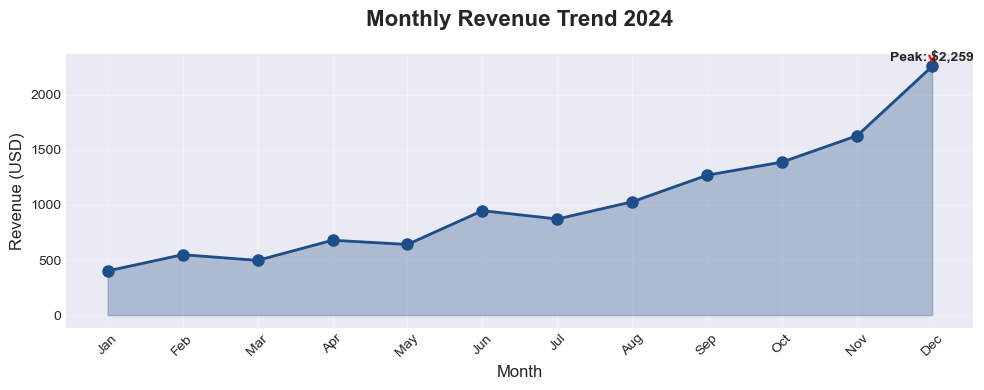

Chart 1 saved successfully


In [14]:
os.makedirs('charts', exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print('='*50)
print("Chart 1: Monthly Revenue Trend")
print("="*50)

fig, ax = plt.subplots(figsize=(10,4))

#Create ordered months list
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec' ]
monthly_data = df.groupby('MonthName')['Revenue'].sum().reindex(month_order)

ax.plot(monthly_data.index, monthly_data.values,
        color = '#1D4E89', marker='o', linewidth=2, markersize=8)
ax.fill_between(monthly_data.index, monthly_data.values, alpha=0.3, color='#1D4E89')

#Find peak month
peak_month = monthly_data.idxmax()
peak_value = monthly_data.max()
ax.annotate(f'Peak: ${peak_value:,.0f}',
            xy=(peak_month, peak_value),
            xytext=(peak_month, peak_value + 50),
            ha='center', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.set_title('Monthly Revenue Trend 2024', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Revenue (USD)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/chart1_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart 1 saved successfully")

The monthly revenue trend shows significant seasonality with a pronounced peak in December (holiday season) reaching over 2000 in revenue. Revenue remained relatively stable between 300 and 1000 for most months, with a notable dip in March and a steady increase from July onward. This pattern suggests the business should stock up inventory and increase marketing spend starting September to maximize holiday sales. 

### Chart 2: Top 10 Products by Revenue

Chart 2: Top 10 Products by Revenue


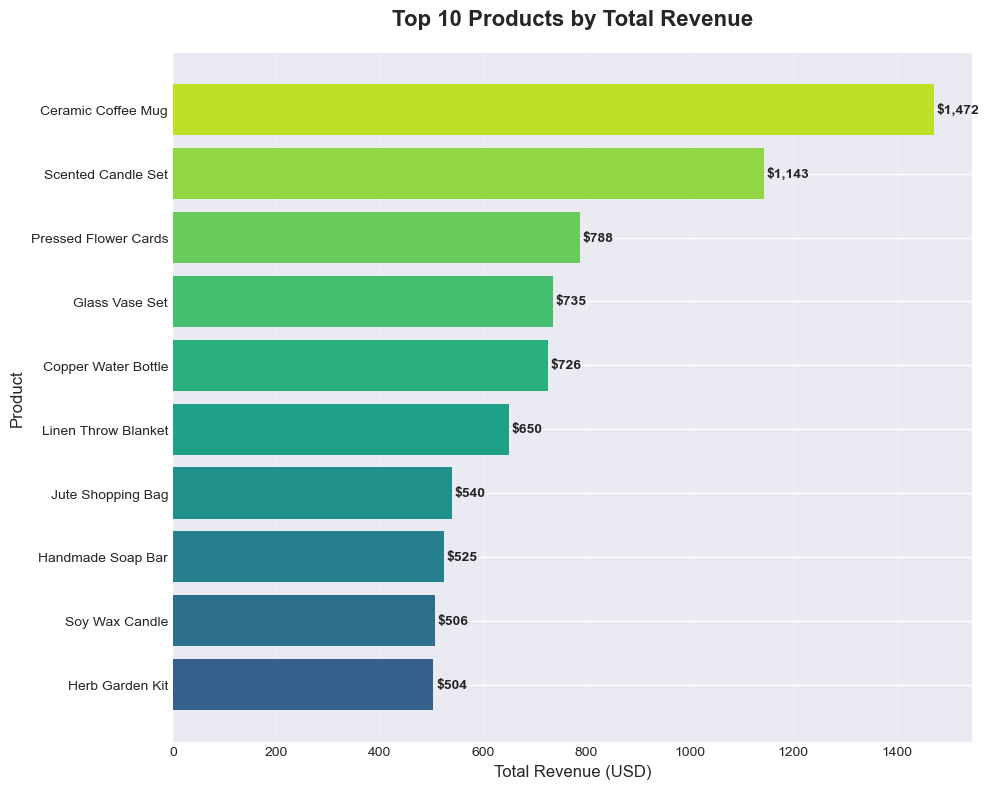

Chart 2 saved successfully


In [15]:
print("="*50)
print("Chart 2: Top 10 Products by Revenue")
print("="*50)

fig, ax = plt.subplots(figsize=(10,8))

product_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=True).tail(10)

colors = plt.cm.viridis(np.linspace(0.3, 0.9, 10))
bars = ax.barh(product_revenue.index, product_revenue.values, color=colors)

#Add value labels
for i, (bar, val) in enumerate(zip(bars, product_revenue.values)):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontweight='bold')

ax.set_title('Top 10 Products by Total Revenue', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Total Revenue (USD)', fontsize=12)
ax.set_ylabel('Product', fontsize=12)
ax.grid(True, alpha = 0.3, axis='x')
plt.tight_layout()
plt.savefig('charts/chart2_top_products.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart 2 saved successfully")

The top 10 products generate majority of revenue with Ceramic Coffee Mug leading at over 1400, followed by Scented Candle Set at slightly over 1100 and the Pressed Flower Cards at approximately 800. This concentration indicates the business relies heavily on a few core products. Management should ensure these bestsellers never go out of stock and consider bundling lower performing products with these top sellers.

### Chart 3: Revenue by Country

Chart 3: Revenue by Country


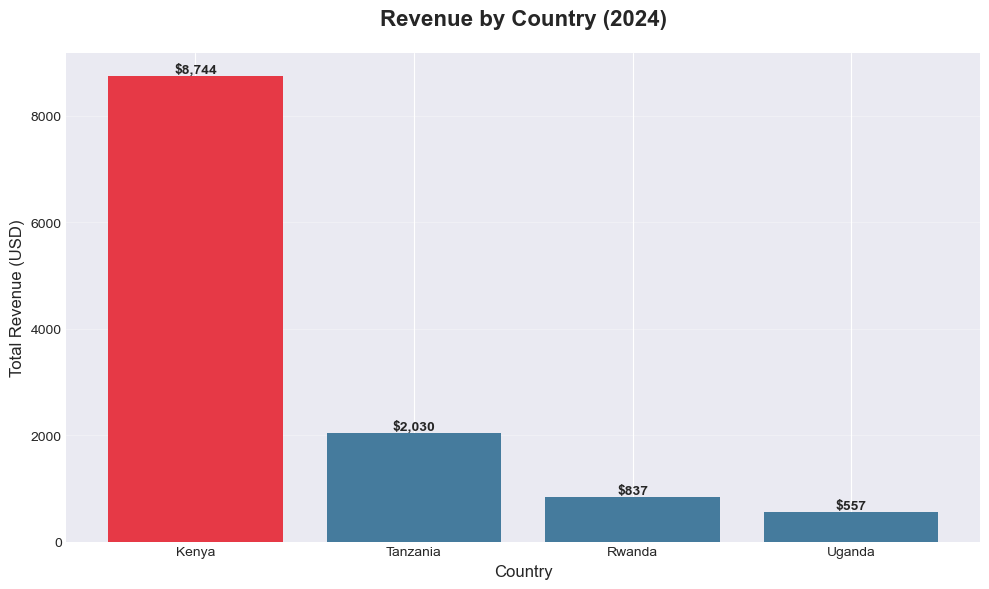

Chart 3 saved successfully


In [16]:
print("="*50)
print("Chart 3: Revenue by Country")
print("="*50)

fig, ax = plt.subplots(figsize=(10, 6))
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

#Highlight Kenya in a different color
colors = ['#E63946' if country == "Kenya" else '#457B9D' for country in country_revenue.index]
bars = ax.bar(country_revenue.index, country_revenue.values, color = colors)

#Add value labels
for bar, val in zip(bars, country_revenue.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'${val:,.0f}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Revenue by Country (2024)', fontsize = 16, fontweight = 'bold', pad = 20)
ax.set_xlabel('Country', fontsize = 12)
ax.set_ylabel('Total Revenue (USD)', fontsize = 12)
ax.grid(True, alpha = 0.3, axis = 'y')
plt.tight_layout()
plt.savefig('charts/chart3_country_revenue.png', dpi = 150, bbox_inches='tight')
plt.show()

print("Chart 3 saved successfully")

Kenya dominates revenue generation contributing about 70% of total sales across all countries. Uganda and Tanzania show moderate performance while Rwanda represents a smaller market. This suggests the company has strongest brand recognition and logistics in Kenya, but also highlights growth opportunities in neighbouring countries through targeted marketing campaigns.

### Revenue by Quarter

Chart 4: Revenue by Quarter


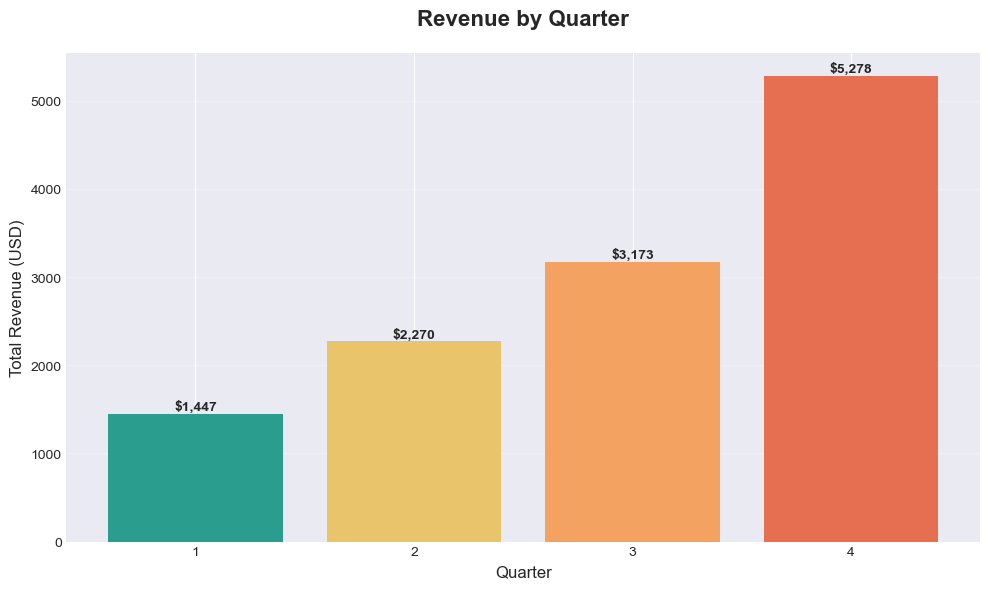

Chart 4 saved succesfully


In [17]:
print("="*50)
print("Chart 4: Revenue by Quarter")
print("="*50)

fig, ax = plt.subplots(figsize=(10,6))
quarterly_revenue = df.groupby('Quarter')['Revenue'].sum()

colors = ['#2A9D8F', '#E9C46A', '#F4A261', '#E76F51']
bars = ax.bar(quarterly_revenue.index.astype(str), quarterly_revenue.values, color=colors)

#Add value labels
for bar, val in zip(bars, quarterly_revenue.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'${val:,.0f}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Revenue by Quarter', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Quarter', fontsize=12)
ax.set_ylabel('Total Revenue (USD)', fontsize = 12)
ax.grid(True, alpha = 0.3, axis = 'y')
plt.tight_layout()
plt.savefig('charts/chart4_quarterly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart 4 saved succesfully")

Revenue shows strong growth progression across quarters with Q1 having the lowest of approximately 1400 followed by Q2 having slighly above 2000. Q3 shows a steady increase up to 3000 and Q4 being the holiday season shooting upto over 5000. The increase from Q2 to Q3 suggests mid-year promotions could help in revenue growth. The 31% increase from Q1 to Q4 demonstrates positive annual growth trajectory.

### Chart 5: Order Value Distribution

Chart 5: Order Value Distribution


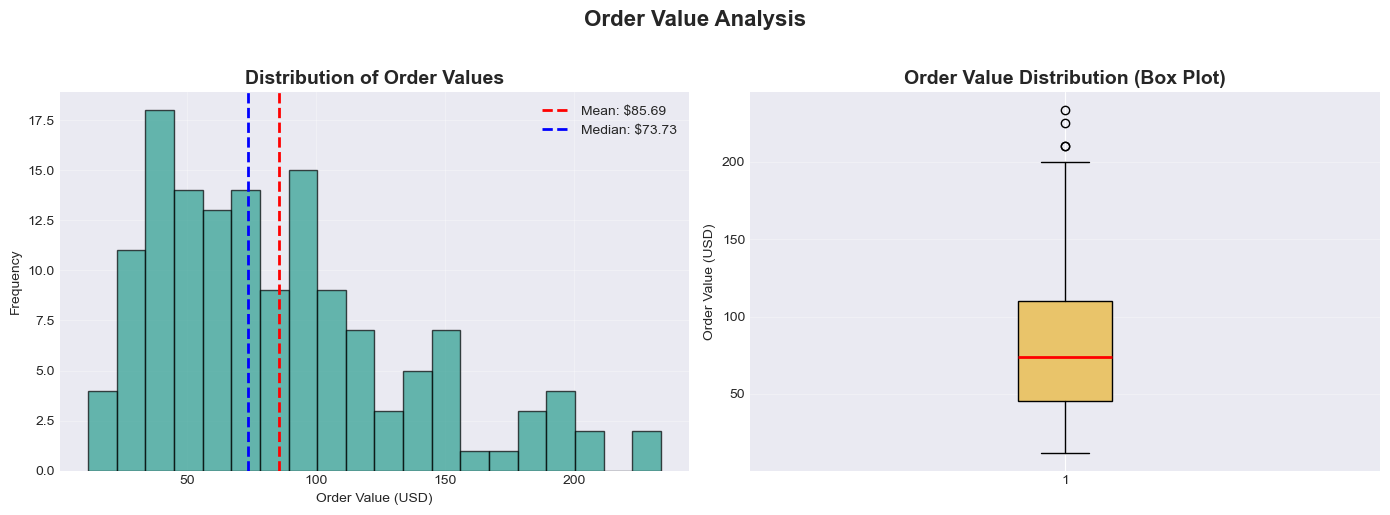

Chart 5 saved successfully

All visualizations saved to charts directory


In [18]:
print("="*50)
print("Chart 5: Order Value Distribution")
print("="*50)

fig, axes = plt.subplots(1,2, figsize=(14,5))
order_values = df.groupby('InvoiceNo')['Revenue'].sum()

#Histogram
axes[0].hist(order_values, bins=20, color='#2A9D8F', edgecolor='black', alpha=0.7)
axes[0].axvline(order_values.mean(), color='red', linestyle='dashed',
                linewidth=2, label=f'Mean: ${order_values.mean():.2f}')
axes[0].axvline(order_values.median(), color='blue', linestyle='dashed',
                linewidth=2, label=f'Median: ${order_values.median():.2f}')
axes[0].set_title("Distribution of Order Values", fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel("Order Value (USD)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#Box plot
box = axes[1].boxplot(order_values, patch_artist=True,
                      boxprops=dict(facecolor='#E9C46A', color='black'),
                      whiskerprops=dict(color='black'),
                      capprops=dict(color='black'),
                      medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Order Value Distribution (Box Plot)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Order Value (USD)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Order Value Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/chart5_order_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart 5 saved successfully")
print("\n" + "="*50)
print("All visualizations saved to charts directory")
print("="*50)

The order value distribution is right-skewed, with most orders falling between 20 and 80. The mean order value ($85.69) exceeds the median order value (73.73), indicating a few high-orders pull the average upwards. Several outlier transactions exceed 200, representing premium purchases. The distribution suggests that the business has both an accessible entry price point and capacity for high-value sales.

## 5. Descriptive Statistics
Summary statistics give the business team a quick, quantitative snapshot. 

In [19]:
#Overall Descriptive Statistics
print("="*50)
print("Descriptive Statistics")
print("="*50)

#Overall Statistics
print("Overall Statistics")
print('-'*40)
print(f"Total Revenue: ${df['Revenue'].sum():,.2f}")
print(f"Average Revenue per Transaction: ${df['Revenue'].mean():.2f}")
print(f"Median Revenue per Transaction: ${df['Revenue'].median():.2f}")
print(f"Total Quantity Sold: {df['Quantity'].sum():,.0f}")
print(f"Average Unit Price: ${df['UnitPrice'].mean():.2f}")
print(f"Number of Transactions: {len(df)}")
print(f"Number of Orders: {df['InvoiceNo'].nunique()}")
print(f"Average Items per Order: {df.groupby('InvoiceNo')['Quantity'].sum().mean():.1f}")

Descriptive Statistics
Overall Statistics
----------------------------------------
Total Revenue: $12,167.73
Average Revenue per Transaction: $85.69
Median Revenue per Transaction: $73.73
Total Quantity Sold: 1,644
Average Unit Price: $12.51
Number of Transactions: 142
Number of Orders: 142
Average Items per Order: 11.6


In [20]:
#Revenue stats by country
print("Revenue Statistics by Country")

country_stats = df.groupby('Country')['Revenue'].agg([
    ('Total Revenue', 'sum'),
    ('Average Revenue', 'mean'), 
    ('Median Revenue', 'median'),
    ('Transaction Count', 'count')
]).round(2).sort_values('Total Revenue', ascending=False)
country_stats

Revenue Statistics by Country


,Total Revenue,Average Revenue,Median Revenue,Transaction Count
Country,,,,
Kenya,8743.54,89.22,81.75,98
Tanzania,2029.94,84.58,67.47,24
Rwanda,837.32,76.12,70.00,11
Uganda,556.93,61.88,38.97,9


In [21]:
#Revenue stats by product
print("Top 10 Products by Total Revenue")

product_stats = df.groupby('Description')['Revenue'].agg([
    ('Total Revenue', 'sum'),
    ('Average per Transaction', 'mean'),
]).round(2).sort_values('Total Revenue', ascending = False).head(10)
product_stats

Top 10 Products by Total Revenue


,Total Revenue,Average per Transaction,Quantity sold
Description,,,
Ceramic Coffee Mug,1471.50,81.75,1471.50
Scented Candle Set,1143.12,103.92,1143.12
Pressed Flower Cards,787.50,131.25,787.50
Glass Vase Set,735.00,91.88,735.00
Copper Water Bottle,726.00,121.00,726.00
Linen Throw Blanket,649.74,92.82,649.74
Jute Shopping Bag,540.00,135.00,540.00
Handmade Soap Bar,525.00,105.00,525.00
Soy Wax Candle,506.25,101.25,506.25


In [22]:
#Single highest-value transaction
print(df.loc[df['Revenue'].idxmax()])

CustomerID                    C043
InvoiceNo                 INV-1141
InvoiceDate    2024-12-28 00:00:00
StockCode                  SKU-B02
Description     Scented Candle Set
Quantity                        18
UnitPrice                    12.99
Country                   Tanzania
Revenue                     233.82
Month                           12
MonthName                      Dec
Quarter                          4
DayOfWeek                 Saturday
WeekdayNum                       5
Name: 140, dtype: object


In [23]:
#Month with the highest total revenue
print("Best Month for Revenue")

monthly_total = df.groupby(['Month', 'MonthName'])['Revenue'].sum().reset_index()
best_month = monthly_total.loc[monthly_total['Revenue'].idxmax()]
print(f"Month: {best_month['MonthName']}")
print(f"Revenue: ${best_month['Revenue']:.2f}")

Best Month for Revenue
Month: Dec
Revenue: $2258.74


In [24]:
#Day of Week Analysis
print("Revenue by Day of Week")

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_stats = df.groupby('DayOfWeek')['Revenue'].sum().reindex(weekday_order)
for day, revenue in weekday_stats.items():
    print(f"{day}: ${revenue:,.2f}")

Revenue by Day of Week
Monday: $1,448.97
Tuesday: $1,727.75
Wednesday: $1,476.33
Thursday: $1,939.36
Friday: $1,840.58
Saturday: $1,522.44
Sunday: $2,212.30


In [25]:
#Summary table
print("\n" + "=" * 60)
print("Summary Table: Key Metrics")
print("="*60)

summary_table = pd.DataFrame({
    'Metric': ['Total Revenue', 'Average Order Value', 'Total Customers', 'Total Products',
               'Top Market', 'Top Product', 'Peak Month', 'Best Day'],
    'Value': [
        f"${df['Revenue'].sum():,.2f}",
        f"${order_summary['TotalRevenue'].mean():.2f}",
        df['CustomerID'].nunique(),
        df['StockCode'].nunique(),
        country_stats.index[0],
        product_stats.index[0],
        best_month['MonthName'],
        weekday_stats.idxmax()
    ]
})
print(summary_table.to_string(index=False))


Summary Table: Key Metrics
             Metric              Value
      Total Revenue         $12,167.73
Average Order Value             $85.69
    Total Customers                 50
     Total Products                 26
         Top Market              Kenya
        Top Product Ceramic Coffee Mug
         Peak Month                Dec
           Best Day             Sunday


From the above cells, the business generated slightly over 12000 dollars in total revenue across 50 customers and 26 products in 2024. 
Kenya has the largest market share by having a total revenue of close to 9000 dollars, which contributes to 70% of the market share, followed by Tanzania having 2029 dollars then Rwanda and Uganda. 
Ceramic Coffee Mugs are the top-selling product having a total revenue of close to 1500 dollars while the average order value stands at 85 dollars.
December shows the strongest performance having a total revenue of over 2000 dollars, suggesting significant seasonal lift during the holidays.
Sunday generates the highest weekday revenue of 2212 dollars

## 6. RFM Customer Segmentation
RFM (Recency, Frequency, Monetary) is the industry standard for ranking customers by value. Scoring customers lets the business allocate marketing budget where it will have the most impact.

In [26]:
print("="*60)
print("RFM Customer Segmentation")
print("="*60)

#Calculating snapshot date (day after last purchase)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"\nAnalysis as of: {snapshot_date.date()}")

#Calculating RFM metrics
rfm = df.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x:
               (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary = ('Revenue', 'sum')
).reset_index()
rfm.to_csv('rfm_segments.csv', index=False)

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
print(f"\nRFM Table Shape: {rfm.shape}")
print(f"Recency range: {rfm['Recency'].min()} - {rfm['Recency'].max()} days")
print(f"Frequency range: {rfm['Frequency'].min()} - {rfm['Frequency'].max()} purchases")
print(f"Monetary range: ${rfm['Monetary'].min():.2f} to ${rfm['Monetary'].max():.2f}")

#Creating RFM scores (1-4 scale)
print("\nCreating RFM Scores (1-4 scale where 4 = best)...")

#For Recency: lower days = better, so rank in reverse
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 4, labels=['4', '3', '2', '1'])

#For Frequency and Monetary: higher = better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=['1', '2', '3', '4'])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=['1', '2', '3', '4'])

#Converting to numeric
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

#Creating combined RFM Score
rfm['RFM_Score'] = rfm['R_Score'] * 100 + rfm['F_Score'] * 10 + rfm['M_Score']
                         

RFM Customer Segmentation

Analysis as of: 2024-12-31

RFM Table Shape: (50, 4)
Recency range: 1 - 204 days
Frequency range: 1 - 6 purchases
Monetary range: $80.00 to $407.50

Creating RFM Scores (1-4 scale where 4 = best)...


In [27]:
#Assigning customer segments based on RFM scores
def assign_segment(row):
    r,f,m = row['R_Score'], row['F_Score'], row['M_Score']

    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions (Best Customers)'
    elif r >=3 and f >= 2 and m >= 2:
        return 'Loyal Customers'
    elif r >= 2 and f >= 1 and m >= 1:
        return 'Potential Loyalists'
    elif r >= 4 and f >= 1 and m >= 1:
        return 'New Customers'
    elif r <= 2 and f >= 2 and m >= 2:
        return 'At Risk'
    elif r <= 1 and f >= 1 and m >= 1:
        return 'Lost'
    elif r >= 2 and f <= 1 and m <= 1:
        return 'Promising'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

#Display RFM results
print("RFM Scores by Customer")

rfm.head(10)

    

RFM Scores by Customer


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,C001,21,6,390.90,4,4,4,444,Champions (Best Customers)
1,C002,13,5,312.97,4,4,4,444,Champions (Best Customers)
2,C003,4,5,198.48,4,4,2,442,Loyal Customers
3,C004,1,5,407.50,4,4,4,444,Champions (Best Customers)
4,C005,204,4,193.50,1,3,1,131,Lost
5,C006,189,4,231.25,1,3,3,133,At Risk
6,C007,179,4,197.47,1,3,2,132,At Risk
7,C008,169,4,169.25,1,4,1,141,Lost
8,C009,162,4,207.50,1,4,2,142,At Risk
9,C010,152,4,243.96,1,4,3,143,At Risk


In [28]:
#Segment distribution
print("Customer Segment Distribution")

segment_counts = rfm['Segment'].value_counts()
segment_percentages = (segment_counts / len(rfm) * 100).round(1)
segment_summary = pd.DataFrame({
    'Count': segment_counts,
    'Percentage': segment_percentages
})
print(segment_summary)

Customer Segment Distribution
                            Count  Percentage
Segment                                      
Potential Loyalists            19        38.0
Champions (Best Customers)     11        22.0
At Risk                        10        20.0
Loyal Customers                 7        14.0
Lost                            3         6.0


In [29]:
#Exporting RFM table
rfm.to_csv('rfm_segments.csv', index=False)
print("RFM table exported to rfm_segments.csv successfully")

RFM table exported to rfm_segments.csv successfully


Creating RFM segment visualization ...


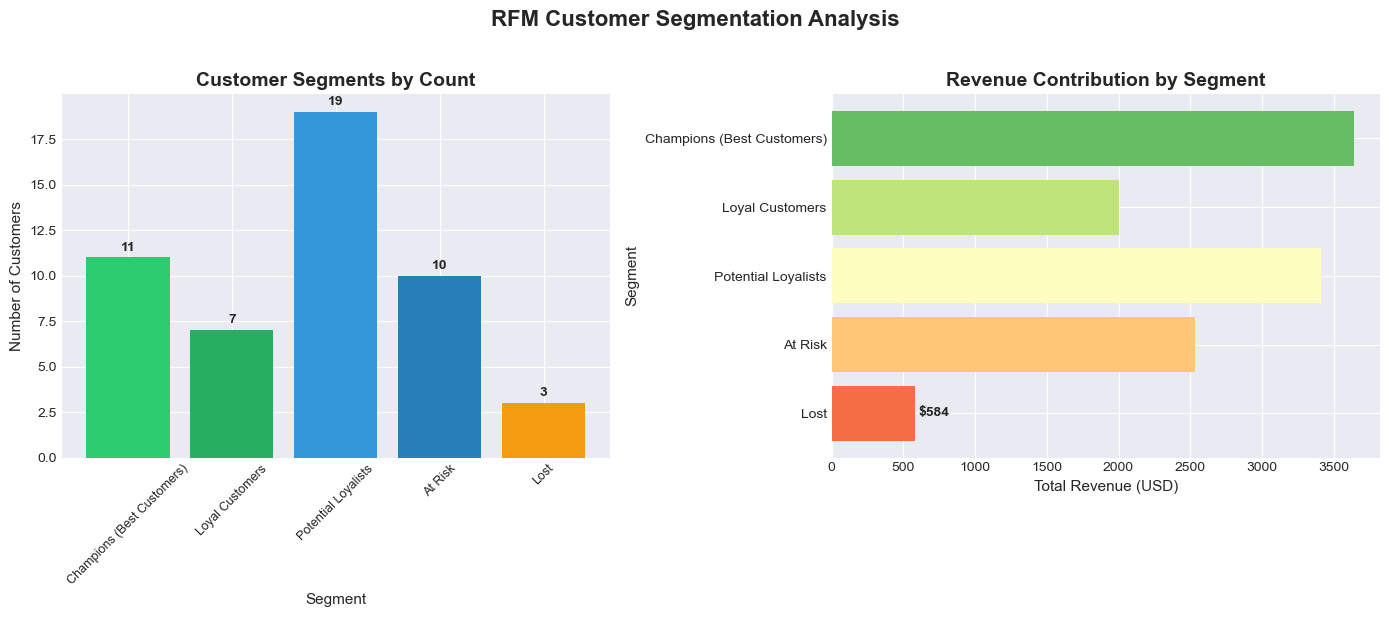

Chart 6 saved successfully!


<Figure size 640x480 with 0 Axes>

Chart 6 saved successfully!


<Figure size 640x480 with 0 Axes>

Chart 6 saved successfully!


<Figure size 640x480 with 0 Axes>

Chart 6 saved successfully!


<Figure size 640x480 with 0 Axes>

Chart 6 saved successfully!


In [30]:
#Visualizing the segments
print("Creating RFM segment visualization ...")

fig, axes = plt.subplots (1,2, figsize=(14,6))

#Bar chart of segment counts
segment_order = ['Champions (Best Customers)', 'Loyal Customers', 'Potential Loyalists',
                 'New Customers', 'Promising', 'At Risk', 'Lost', 'Others']
segment_counts = rfm['Segment'].value_counts()
segment_counts = segment_counts.reindex([s for s in segment_order if s in segment_counts.index])

colors = ['#2ECC71', '#27AE60', '#3498DB', '#2980B9', '#F39C12', '#E67E22', '#E74C3C', '#95A5A6']
bars = axes[0].bar(segment_counts.index, segment_counts.values, color=colors[:len(segment_counts)])
axes[0].set_title('Customer Segments by Count', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Segment', fontsize = 11)
axes[0].set_ylabel('Number of Customers', fontsize = 11)
axes[0].tick_params(axis='x', rotation = 45, labelsize = 9)

#Add value labels
for bar, val in zip(bars, segment_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(val), ha='center', va='bottom', fontweight='bold')

#Monetary value by segment
segment_monetary = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=True)
segment_monetary = segment_monetary.reindex([s for s in segment_order if s in segment_monetary.index][::-1])

colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(segment_monetary)))
bars2 = axes[1].barh(segment_monetary.index, segment_monetary.values, color=colors_bar)
axes[1].set_title('Revenue Contribution by Segment', fontsize = 14, fontweight='bold')
axes[1].set_xlabel('Total Revenue (USD)', fontsize=11)
axes[1].set_ylabel('Segment', fontsize=11)

#Add value labels
for bar, val in zip(bars2, segment_monetary.values):
    axes[1].text(val + 20, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontweight='bold')
    plt.suptitle('RFM Customer Segmentation Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('charts/chart6_rfm_segments.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Chart 6 saved successfully!")

In [31]:
#Strategic Recommendations
print("\n" + "=" * 60)
print("STRATEGIC RECOMMENDATIONS BY SEGMENT")
print("=" * 60)

for segment in segment_order:
    if segment in segment_counts.index:
        count = segment_counts[segment]
        revenue = segment_monetary.get(segment, 0)
        print(f"\n{segment} ({count} customers, ${revenue:,.0f} revenue):")
        if segment == 'Champions (Best Customers)':
            print("-> VIP treatment, exclusive previews, loyalty rewards")
        elif segment == 'Loyal Customers':
            print("-> Upsell opportunities, referral programs, membership benefits")
        elif segment == 'Potential Loyalists':
            print("-> Engagement campaigns, product recommendations, email nurturing")
        elif segment == 'New Customers':
            print("-> Onboarding sequence, welcome discounts, education content")
        elif segment == 'Promising':
            print("-> Cross-sell campaingns, increase purchase frequency incentives")
        elif segment == 'At Risk':
            print("-> Win-back campaigns, personalized offers, feedback surveys")
        elif segment == 'Lost':
            print("-> Re-engagement with major discounts, last-chance offers")
        else:
            print("-> Monitor and identify growth opportunities")


STRATEGIC RECOMMENDATIONS BY SEGMENT

Champions (Best Customers) (11 customers, $3,640 revenue):
-> VIP treatment, exclusive previews, loyalty rewards

Loyal Customers (7 customers, $2,002 revenue):
-> Upsell opportunities, referral programs, membership benefits

Potential Loyalists (19 customers, $3,409 revenue):
-> Engagement campaigns, product recommendations, email nurturing

At Risk (10 customers, $2,533 revenue):
-> Win-back campaigns, personalized offers, feedback surveys

Lost (3 customers, $584 revenue):
-> Re-engagement with major discounts, last-chance offers


* RFM analysis segmented 50 customers into 5 groups. Champions, having 11 customers, generated 3640 dollars in revenue.
* Loyal customers generated approximately 2000 dollars with 7 customers.
* Potential loyalists, having the highest number of customers (19), generated about 3400 dollars.
* At risk customers (10) generated slightly over 2500 dollars in revenue.
* Last but not least, lost customers, although they were just 3, generated close to 600 dollars in revenue.

  This segmentation allows targeted marketing:
* Invest retention budget in Champions by giving them loyalty rewards and exclusive previews.
* Have membership benefits for Loyal Customers.
* Give product recommendations and engagement campaigns for Potential Loyalists.
*  Provide personalized offers and win-back campaigns for At Risk customers.
*  Do re-engagement with major discounts for Lost customers.

## 7. Hypothesis Test and Conclusions

In [32]:
print("=" * 50)
print("Hypothesis Testing: Kenya vs Other Countries")
print("=" * 50)

#Prepare data for t-test
kenya_revenue = df[df['Country'] == 'Kenya']['Revenue']
other_revenue = df[df['Country'] != 'Kenya']['Revenue']

print(f"\nKenya sample size: {len(kenya_revenue)} transactions")
print(f"Other countries sample size: {len(other_revenue)} transactions")
print(f"\nKenya mean revenue: ${kenya_revenue.mean():.2f}")
print(f"Other countries mean revenue: ${other_revenue.mean():.2f}")
print(f"Difference: ${kenya_revenue.mean() - other_revenue.mean():.2f}")

Hypothesis Testing: Kenya vs Other Countries

Kenya sample size: 98 transactions
Other countries sample size: 44 transactions

Kenya mean revenue: $89.22
Other countries mean revenue: $77.82
Difference: $11.40


### State the hypotheses
H0 (Null Hypothesis): Mean revenue from Kenya is not greater than mean revenue from other countries.

H1 (Alternative Hypothesis): Mean revenue from Kenya is greater than mean revenue from other countries.

Test Type: One-tailed independent t-test (alternative = 'greater')

Significance Level: α = 0.05 (95% confidence)

In [33]:
#Performing the t-test
t_stat, p_value = stats.ttest_ind(kenya_revenue, other_revenue, alternative = 'greater')

print("\n" + "=" * 50)
print("Test Results")
print("=" * 50)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")


Test Results
t-statistic: 1.2637
p-value: 0.104226


In [34]:
#Interpreting the results
print("\n" + "=" *50)
print("Conclusion")
print("=" * 50)

if p_value < 0.05:
    print(f"Reject the null hypothesis (p = {p_value:.4f} < 0.05")
    print("There is statistically significant evidence that Kenya generates higher average revenue per transaction than other countries.")
else:
    print(f"Fail to the reject the null hypothesis (p = {p_value:.4f} > 0.05)")
    print("There is not sufficient statistical evidence that Kenya generates higher average revenue per transaction than other countries.")


Conclusion
Fail to the reject the null hypothesis (p = 0.1042 > 0.05)
There is not sufficient statistical evidence that Kenya generates higher average revenue per transaction than other countries.


In [35]:
#Calculating effect size (Cohen's d)
pooled_std = np.sqrt((kenya_revenue.std()**2 + other_revenue.std()**2)/2)
cohens_d = (kenya_revenue.mean() - other_revenue.mean())/ pooled_std

print(f"\nEffect Size (Cohen's d): {cohens_d:.3f}")
if abs(cohens_d) >= 0.8:
    print("Interpretation: Large effect (>0.8)")
elif abs(cohens_d) >= 0.5:
    print("Interpretation: Medium effect (0.5 - 0.8)")
elif abs(cohens_d) >= 0.2:
    print("Interpretation: Small effect (0.2 - 0.5)")
else: 
    print("Interpretation: Negligible effect (<0.2)")



Effect Size (Cohen's d): 0.229
Interpretation: Small effect (0.2 - 0.5)


# Retail Sales Analysis 2024 - Executive Summary
## 1. Introduction
This analysis examined 142 transactions from an East African online gift retailer across Kenya, Uganda, Tanzania and Rwanda from January to December 2024. The objective was to identify revenue drivers, customer segments and actionable business insights. The analysis includes: data cleaning, feature engineering, exploratory visualization, RFM customer segmentation and statistical hypothesis testing.

## 2. Key Findings
### i.) Revenue & Products
* Total annual revenue: 12,167 dollars across 50 customers and 26 products
* Top 3 products generate approximately 30% of revenue (Ceramic Coffee Mug, Scented Candle Set, Pressed Flower Cards)
* December accounts for 18% of annual revenue ($2258)

### ii.) Geographic Performance
* Kenya dominates with 70% market share ($8744)
* Tanzania: 2030 dollars (16%), Rwanda: 837 dollars (6%), Uganda: 557 dollars (4%)

### iii.) Customer Insights
* RFM segmentation identified 11 Champion customers generating 3640 dollars in revenue which equates to 30% of the total revenue.
* 13 dollars are 'At Risk' or 'Lost', putting over 3000 dollars of revenue at stake. This contributes to 25% of the total revenue.
* Potential Loyalists, which is the largest group, carrying almost 20 customers and generating 3400 dollars in revenue need some effort in product recommendations and engagement campaigns to keep them hooked.
* The average order value is 85 dollars and the median order value stands at 73 dollars which makes the order value distribution to be right-skewed.

### iv.) Seasonality
* Quartile 4 shows the strongest performance amongst the quartiles, with December being the peak due to the festive season.
* Sunday shows the highest daily revenue.
* March, May and July show slower periods due to the decline in total sales.

## 3. Recommendations
### Immediate Actions:
1. Increase inventory of the top 3 products 3 months before December.
2. Launch Kenya-specific loyalty program for Champion segment
3. Implement win-back campaign for the 13 At Risk/Lost customers.

### Marketing Strategy:
1. Allocate 60% of marketing budget to Kenya, 40% to expansion markets.
2. Sunday promotional campaigns to maximize high-conversion day.
3. Bundle slow-moving products with Ceramic Coffee Mugs.

### Customer Retention
1. VIP tier for Champions with exclusive early access.
2. Onboarding email sequence for Potential Loyalists.
3. Reactivation offers (20-30% discount) for At Risk segment.

## 4. Limitations
* Small sample size (142 transactions, 50 customers) limits generalizability.
* There is no profitability data (only revenue) hence cannot assess margin per product.
* There are missing customer demographics such as age, gender, income for deeper segmentation.
* The data is only for 1 year (2024) hence cannot validate seasonal patterns across multiple years.
* There is no competitive or market share context for East African region.

## 5. Next Steps
* Collect 2025 data to validate seasonal patterns
* Implement A/B testing for recommended marketing campaigns.
* Deploy automated RFM scoring monthly for real-time targeting.
* Add customer acquisition channel data to optimize marketing spend.
